In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_trend(length, slope, type='linear'):
    # type is linear, quadratic, exponential
    x = np.arange(length)
    if type == 'linear':
        return x * slope
    elif type == "quadratic":
        return (x ** 2) * slope
    elif type == 'exponential':
        return np.exp(slope * x)
    else:
        raise ValueError("Invalid trend type. Choose from 'linear', 'quadratic', or 'exponential'.")
    
def generate_seasonality(length, amplitude, frequency, seasonality_type='sine'):
    #Repeating patterns at regular intervals (e.g., daily, weekly, monthly, or yearly).
    #The period or frequency can be used to mimic short term or long term processes
    #Can be modeled using block, sawtooth, or sine/cosine functions
    x = np.arange(length)
    period = length/frequency

    if seasonality_type == 'sine':
        return amplitude * np.sin(2 * np.pi * frequency * x / length)
    if seasonality_type == 'block':
        return amplitude * np.sign(np.sin(2 * np.pi * x / period))
    elif seasonality_type == 'sawtooth':
        #return amplitude * (1-2*(x % period) / period)
        return amplitude * (2 * ((x / period + 0.25) % 1) - 1)  # shift to start at 0
    
    else:
        raise ValueError("Unsupported seasonality_type. Choose 'sine', 'block', or 'sawtooth'.")
    
def generate_noise(length, scale, noise_type):
    #type: normal or uniform
    if noise_type == "normal":
        return np.random.normal(0, scale, size=length)
    elif noise_type == "uniform":
        return np.random.uniform(-scale, scale, size=length)
    else:
        raise ValueError("Invalid noise_type. Choose 'normal' or 'uniform'.")


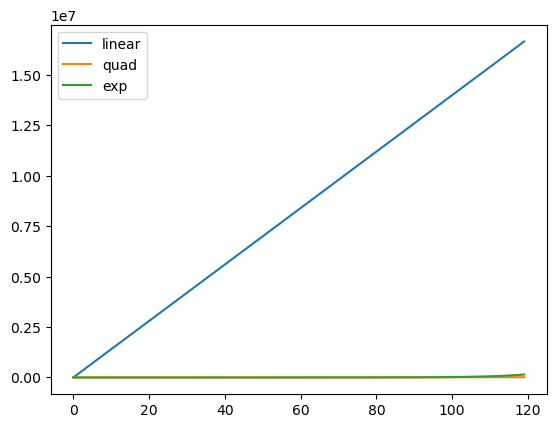

In [2]:
lenght_test = 120
x = np.arange(lenght_test)
linear = generate_trend(lenght_test, 140000, type="linear")
plt.plot(x, linear)

quadratic = generate_trend(lenght_test, 1, type="quadratic")
plt.plot(x, quadratic)

exponential = (generate_trend(lenght_test,0.1, type='exponential'))
plt.plot(x, exponential)
plt.legend(['linear', 'quad', 'exp'])
plt.show()

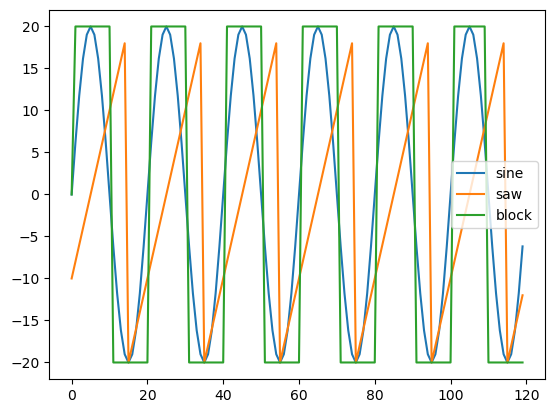

In [3]:
season_sine = generate_seasonality(lenght_test, 20, 6, seasonality_type='sine')

season_saw = generate_seasonality(lenght_test, 20, 6, seasonality_type='sawtooth')
season_block = generate_seasonality(lenght_test, 20, 6, seasonality_type='block')
plt.plot(x, season_sine)
plt.plot(x, season_saw)
plt.plot(x, season_block)
plt.legend(['sine', 'saw', 'block'])
plt.show()

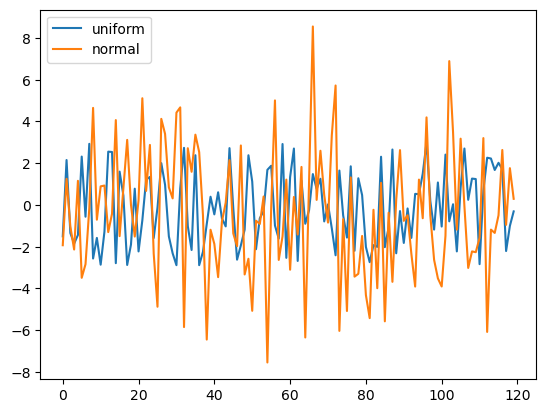

In [5]:
uniform_nois = generate_noise(lenght_test, 3, noise_type='uniform')
normal_noise = generate_noise(lenght_test, 3, noise_type='normal')

plt.plot(x, uniform_nois)
plt.plot(x, normal_noise)
plt.legend(['uniform', 'normal'])
plt.show()